In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import requests
import json
from typing import Annotated
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
import ollama 
from tqdm.auto import tqdm
import csv
from langgraph.types import Command

In [2]:
detect_news_prompt = ("""
    detect_news_prompt = (
    "You are a fact-checker. Analyze this news article for authenticity: {news}\n"
    "Look for inconsistencies, unusual sources, emotional language, or lack of verifiable facts.\n"
    "Use these previous strategies to inform your analysis: {strategy} "
    "these past strategies are the reasoning of the expert jornlaist, use this as an refrence for analysis \n"
    "Classify it as Fake or Real and provide a detailed explanation for your decision.\n"
    "Be objective and thorough in your assessment. Limit your response to 200 tokens. Don't hallucinate\n"
)
""")


reflect_news_prompt = (
    "You are an LLM Reflector, an expert in analyzing fact-checking errors.\n\n"
    "TASK: The Detector incorrectly classified this news article. The actual label is {actual_label}, "
    "but the Detector classified it as {detector_classification}.\n\n"
    "NEWS ARTICLE: {news}\n\n"
    "DETECTOR'S EXPLANATION: {detector_explanation}\n\n"
    "Generate specific reflection feedback addressing:\n"
    "1. The exact errors in the Detector's reasoning\n"
    "2. Evidence supporting why this article should be classified as {actual_label}\n"
    "3. Concrete strategy recommendations to improve future classifications\n\n"
    "Your feedback will be used to automatically refine the Detector's approach. Be precise and evidence-driven.\n"
    "Limit your response to 200 tokens.\n"
)



In [3]:
class DetectorState(BaseModel):
    explanation: str = Field(
        description="Step-by-step reasoning behind the 'classification'"
    )
    classification: Literal['Fake', 'Real'] = Field(
        description="The classification of an detected news: \n"
        "'Real' for the news, detector classifies Real\n"
        "'Fake' for the news, detector classifies Fake\n"
    )

class RefelectorState(BaseModel):
    explanation: str = Field(
        description="Step-by-step reasoning where the model classified the news artice incorrectly"
    )

class OverallState(TypedDict):
    current_news: str
    actual_label: str
    current_detector_classification: str
    current_detector_explanation: str
    current_reflector_explanation: str
    reflector_strat: str

In [4]:
def update_strats(state: OverallState) -> OverallState:
    if state['current_detector_classification'] != state['actual_label']:  
        if state['current_reflector_explanation']:
            new_explanation = state["current_reflector_explanation"]  
            return {
                "reflector_strat": new_explanation,
            }
        else:
            return {
                "reflector_strat": "",
            }
    else:
        return {
            "reflector_strat": "",
        }

    
def detector_strategy(state: OverallState):
    if state["reflector_strat"]:
        conditioning = f"Reflector Strategies: {state['reflector_strat']})"
    else:
        conditioning = ""
    return conditioning

def detector(state: OverallState): 
    strategy = detector_strategy(state)
    prompt = detect_news_prompt.format(news=state['current_news'], strategy=strategy)
    
    try:
        # Using Ollama's structured output support
        response = ollama.chat(
            messages=[{"role": "user", "content": prompt}],
            model="detector:latest",
            format=DetectorState.model_json_schema(),  # Pass schema directly
            options={
                "temperature": 0.2,
                "num_predict": 256,
                "seed": 42
            }
        )
        
        # Parse JSON response into Pydantic model
        result = DetectorState.model_validate_json(response.message.content)

        return {
            'current_detector_classification': result.classification,
            'current_detector_explanation': result.explanation
        }
        
    except Exception as e:
        print(f"Error in detector function: {e}")
        # Fallback in case of error
        return {
            'current_detector_classification': "Fake",
            'current_detector_explanation': f"Error: {str(e)}"
        }

def reflector(state: OverallState):
    prompt = reflect_news_prompt.format(
        news=state['current_news'],
        actual_label=state['actual_label'],
        detector_classification=state['current_detector_classification'],
        detector_explanation=state['current_detector_explanation']
    )

    try:
        response = ollama.chat(
            messages=[{"role": "user", "content": prompt}],
            model="llama3.2:1b",
            format=RefelectorState.model_json_schema(),  # Pass schema directly
            options={
                "temperature": 0.9,
                "num_predict": 256, 
                "seed": 42
            }
        )
        result = RefelectorState.model_validate_json(response.message.content) 
        return {
            'current_reflector_explanation': result.explanation
        }
    except Exception as e:
        print(f"Error in generator function: {e}")
        return {
            'current_reflector_explanation': f"{e}"
        }
    
def check_validity(state: OverallState) -> Command[Literal["reflector", "__end__"]]:
    if state['current_detector_classification'] != state['actual_label']:
        goto = ["reflector"]
    else:
        goto = "__end__"
    
    return Command(
        goto=goto
    )

In [5]:
graph = StateGraph(OverallState)
graph.add_node("update", update_strats)
graph.add_node("detector", detector)
graph.add_node("reflector", reflector)
graph.add_node("valid", check_validity)
graph.add_edge(START, "update")
graph.add_edge("update", "detector")
graph.add_edge("detector", "valid")
graph.add_edge("reflector", END)
app = graph.compile()

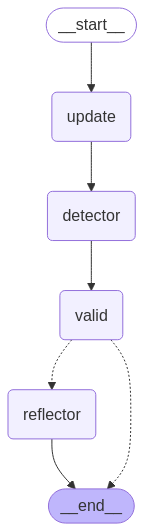

In [6]:
from IPython.display import display, Image

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [7]:
state = {
    "current_news": "",
    "actual_label": "",
    "current_detector_classification": "",
    "current_detector_explanation": "",
    "current_reflector_explanation": "",
    "reflector_strat": ""
}

In [8]:
def write_to_csv(data, filename='testresults.csv'):
    fieldnames = ['news', 'actual_label', 'classification', 'detector_explanation', 'reflector_strategy']
    
    with open(filename, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)

        if file.tell() == 0:
            writer.writeheader()
        
        writer.writerow(data)

In [9]:
news = pd.read_csv('test_data.csv')
for index, row in tqdm(news.iterrows()):
    initial_state = state.copy()
    state["actual_label"] = row["label"]   
    state["current_news"] = row["text"]
    state = app.invoke(state)
    
    csv_data = {
        'news': state["current_news"],
        'actual_label': state["actual_label"],
        'classification': state["current_detector_classification"],
        'detector_explanation': state["current_detector_explanation"],
        'reflector_strategy': state['reflector_strat']
    }
    
    # Write data to CSV
    write_to_csv(csv_data)

0it [00:00, ?it/s]

Error in generator function: 1 validation error for RefelectorState
  Invalid JSON: EOF while parsing a string at line 1 column 1297 [type=json_invalid, input_value='{"explanation": "The Det...sing training data that', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/json_invalid
Error in generator function: 1 validation error for RefelectorState
  Invalid JSON: EOF while parsing a string at line 1 column 1280 [type=json_invalid, input_value='{"explanation": "The Det...d formats and citations', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/json_invalid
Error in generator function: 1 validation error for RefelectorState
  Invalid JSON: EOF while parsing an object at line 2 column 0 [type=json_invalid, input_value='{ "explanation": "Detect...e in opinion pieces."\n', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/json_invalid
Error in generator function: 1 validation error for

In [10]:
news

,label,text
0,REAL,The National Federation of Independent Busines...
1,FAKE,Legislation to provide 81 billion in new disas...
2,REAL,U.S. President Donald Trump told Chinese Presi...
3,FAKE,The U.S. Congress may be able to wrap up tax n...
4,FAKE,House Speaker Paul Ryan has told President Don...
...,...,...
495,FAKE,U.S. Republican Senator Mike Lee has not decid...
496,REAL,British Prime Minister Theresa May said on Thu...
497,REAL,U.S. President Donald Trump arrived in the Phi...
498,REAL,U.S. President Donald Trump s former campaign ...
